In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

sns.set_theme(style="whitegrid")

In [3]:
df = pd.read_csv("retail_sales_dataset.csv")

In [5]:
df.head()

,order_id,order_date,customer_id,customer_name,age,gender,region,city,product_category,product_name,...,unit_price,discount_pct,sales_amount,profit,shipping_cost,payment_method,customer_satisfaction,return_flag,order_status,days_to_ship
0,ORD-03903,2024-08-15,CUST32603,Aarav Mehta,39.0,Other,Central,Raipur,Groceries,Sugar,...,346.32,NaN,4043.14,289.18,56.04,Debit Card,NaN,True,Returned,7.0
1,ORD-02198,2022-08-16,CUST07881,Sanjay Verma,28.0,Male,West,Mumbai,Beauty,Sunscreen,...,858.66,0.08,9147.31,5355.56,64.49,Debit Card,5.0,False,Delivered,2.0
2,ORD-01348,2021-08-29,CUST49296,Pooja Sharma,41.0,Other,West,Surat,Furniture,Sofa,...,25941.32,0.14,110156.97,36956.51,67.65,Debit Card,4.0,False,Delivered,5.0
3,ORD-02076,2022-07-05,CUST05587,Priya Reddy,29.0,Other,West,Ahmedabad,Furniture,Bed Frame,...,22071.92,0.17,262066.11,66644.99,54.47,EMI,3.0,False,Delivered,4.0
4,ORD-00287,2020-05-07,CUST58035,Ritu Sharma,9.0,Male,Central,Nagpur,Groceries,Cooking Oil,...,320.06,0.31,323.95,31.38,48.81,Net Banking,4.0,False,Pending,4.0


In [6]:
print("Shape of dataset:", df.shape)

print("\nColumn names:")
print(df.columns)

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

Shape of dataset: (4310, 21)

Column names:
Index(['order_id', 'order_date', 'customer_id', 'customer_name', 'age',
       'gender', 'region', 'city', 'product_category', 'product_name',
       'quantity', 'unit_price', 'discount_pct', 'sales_amount', 'profit',
       'shipping_cost', 'payment_method', 'customer_satisfaction',
       'return_flag', 'order_status', 'days_to_ship'],
      dtype='str')

Data types:
order_id                     str
order_date                   str
customer_id                  str
customer_name                str
age                      float64
gender                       str
region                       str
city                         str
product_category             str
product_name                 str
quantity                 float64
unit_price               float64
discount_pct             float64
sales_amount             float64
profit                   float64
shipping_cost            float64
payment_method               str
customer_satisfaction  

In [7]:
# Check missing values clearly
missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values[missing_values > 0])

print("\nTotal missing values:", df.isnull().sum().sum())

print("\nTotal duplicate rows:", df.duplicated().sum())

Missing values in each column:
order_id                  30
order_date                30
customer_id               30
customer_name             30
age                      160
gender                    30
region                    30
city                      30
product_category          30
product_name              30
quantity                 140
unit_price                30
discount_pct             167
sales_amount              30
profit                    30
shipping_cost             30
payment_method            30
customer_satisfaction    378
return_flag               30
order_status              30
days_to_ship             130
dtype: int64

Total missing values: 1455

Total duplicate rows: 109


In [8]:
# Check numerical columns
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,4150.0,35.335181,35.709382,-7.00,26.0000,34.000,42.0000,999.00
quantity,4170.0,7.379856,43.578352,-1.00,3.0000,5.000,8.0000,999.00
unit_price,4280.0,10621.154428,17323.704016,50.26,672.2225,2228.435,12717.4350,79957.92
discount_pct,4143.0,0.202085,0.118095,0.00,0.1000,0.210,0.3100,0.40
sales_amount,4280.0,62358.637619,316699.811253,39.45,2462.1650,9548.075,50069.6425,17360314.17
profit,4280.0,11687.125054,52875.219339,1.56,701.8225,3128.005,10403.7200,2445648.43
shipping_cost,4280.0,63.358836,18.312281,-4.29,50.8175,63.465,75.6500,133.35
customer_satisfaction,3932.0,3.016531,1.413127,1.00,2.0000,3.000,4.0000,5.00
days_to_ship,4180.0,5.620335,4.178663,-1.00,3.0000,6.000,8.0000,100.00


In [9]:
# Check age values
print("Minimum age:", df["age"].min())
print("Maximum age:", df["age"].max())

print("\nAge summary:")
print(df["age"].describe())

Minimum age: -7.0
Maximum age: 999.0

Age summary:
count    4150.000000
mean       35.335181
std        35.709382
min        -7.000000
25%        26.000000
50%        34.000000
75%        42.000000
max       999.000000
Name: age, dtype: float64


In [10]:
# Check duplicate rows
df[df.duplicated()].head()

,order_id,order_date,customer_id,customer_name,age,gender,region,city,product_category,product_name,...,unit_price,discount_pct,sales_amount,profit,shipping_cost,payment_method,customer_satisfaction,return_flag,order_status,days_to_ship
144,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
432,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
516,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
540,ORD-00881,2021-02-02,CUST31073,Kavya Shah,48.0,Male,East,Bhubaneswar,Groceries,Flour,...,474.48,0.26,2258.19,189.8,40.18,Debit Card,1.0,True,Returned,2.0
630,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
# Count duplicates
df.duplicated().sum()

np.int64(109)

In [12]:
# Check unrealistic age values
df[(df["age"] < 18) | (df["age"] > 80)]["age"].value_counts().sort_index()

age
-7.0       2
-6.0       1
-5.0       4
-4.0       2
-2.0       2
-1.0       2
 0.0       5
 1.0       2
 2.0       3
 3.0       9
 4.0       5
 5.0       8
 6.0      11
 7.0      10
 8.0      12
 9.0      11
 10.0     13
 11.0     18
 12.0     30
 13.0     22
 14.0     43
 15.0     49
 16.0     38
 17.0     36
 150.0     3
 999.0     5
Name: count, dtype: int64

In [13]:
# Check unrealistic shipping days
df[df["days_to_ship"] < 0]["days_to_ship"].value_counts()

days_to_ship
-1.0    5
Name: count, dtype: int64

In [14]:
# Remove exact duplicate rows
df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (4201, 21)


In [15]:
# Replace unrealistic age values with missing values
df.loc[(df["age"] < 18) | (df["age"] > 80), "age"] = np.nan

print("Missing age values after cleaning:", df["age"].isnull().sum())

Missing age values after cleaning: 463


In [16]:
# Replace invalid negative shipping days with missing values
df.loc[df["days_to_ship"] < 0, "days_to_ship"] = np.nan

print("Missing shipping days after cleaning:",
      df["days_to_ship"].isnull().sum())

Missing shipping days after cleaning: 103


In [17]:
# Complete missing-value summary
missing = df.isnull().sum()

missing_summary = pd.DataFrame({
    "Missing Values": missing,
    "Percentage": (missing / len(df) * 100).round(2)
})

missing_summary[missing_summary["Missing Values"] > 0].sort_values(
    by="Missing Values",
    ascending=False
)

,Missing Values,Percentage
age,463,11.02
customer_satisfaction,347,8.26
discount_pct,136,3.24
quantity,109,2.59
days_to_ship,103,2.45
customer_name,1,0.02
customer_id,1,0.02
order_date,1,0.02
order_id,1,0.02
product_category,1,0.02


In [18]:
# Fill missing numerical values with their median

numerical_columns = [
    "age",
    "customer_satisfaction",
    "discount_pct",
    "quantity",
    "days_to_ship"
]

for column in numerical_columns:
    df[column] = df[column].fillna(df[column].median())

print("Missing values after filling numerical columns:")
print(df[numerical_columns].isnull().sum())

Missing values after filling numerical columns:
age                      0
customer_satisfaction    0
discount_pct             0
quantity                 0
days_to_ship             0
dtype: int64


In [19]:
# Remove rows with missing values in important fields

important_columns = [
    "order_id",
    "order_date",
    "customer_id",
    "customer_name",
    "gender",
    "region",
    "city",
    "product_category",
    "product_name",
    "unit_price",
    "sales_amount",
    "profit",
    "payment_method",
    "shipping_cost",
    "return_flag",
    "order_status"
]

df = df.dropna(subset=important_columns)

print("Shape after cleaning:", df.shape)

Shape after cleaning: (4200, 21)


In [20]:
print("Total missing values:", df.isnull().sum().sum())
print("Total duplicate rows:", df.duplicated().sum())

Total missing values: 0
Total duplicate rows: 0


In [21]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,4200.0,35.968571,9.754816,18.00,29.0000,35.000,42.0000,72.00
quantity,4200.0,7.356905,43.421197,-1.00,3.0000,5.000,8.0000,999.00
unit_price,4200.0,10702.729695,17408.776463,50.26,680.8175,2246.005,12828.9775,79957.92
discount_pct,4200.0,0.202138,0.116126,0.00,0.1000,0.210,0.3000,0.40
sales_amount,4200.0,62921.382033,319512.577675,39.45,2472.2950,9647.895,50524.8500,17360314.17
profit,4200.0,11790.275017,53352.188187,1.56,712.0700,3169.875,10510.9575,2445648.43
shipping_cost,4200.0,63.378790,18.317527,-4.29,50.8275,63.460,75.6550,133.35
customer_satisfaction,4200.0,3.016429,1.354508,1.00,2.0000,3.000,4.0000,5.00
days_to_ship,4200.0,5.639762,4.142208,0.00,3.0000,6.000,8.0000,100.00


In [22]:
df[df["quantity"] > 50][["order_id", "product_name", "quantity", "unit_price", "sales_amount"]].sort_values(
    by="quantity",
    ascending=False
)

,order_id,product_name,quantity,unit_price,sales_amount
242,ORD-00751,Cook Book,999.0,403.63,203951.50
1012,ORD-01242,Self-Help Book,999.0,545.25,729651.06
1112,ORD-00539,Jacket,999.0,2567.40,2281458.22
1138,ORD-01025,Tennis Racket,999.0,9380.72,7936261.20
1700,ORD-00689,Rice (5kg),999.0,195.29,140042.31
2178,ORD-01732,Fiction Novel,999.0,709.64,533420.31
2582,ORD-00809,Jeans,999.0,3280.13,2586345.13
3865,ORD-02560,Tablet,999.0,18619.45,17360314.17


In [23]:
# Replace unrealistic quantity value with median
quantity_median = df["quantity"].median()

df.loc[df["quantity"] > 50, "quantity"] = quantity_median

print("Median quantity:", quantity_median)
print("Maximum quantity after cleaning:", df["quantity"].max())

Median quantity: 5.0
Maximum quantity after cleaning: 10.0


In [24]:
print("Final dataset shape:", df.shape)
print("Total missing values:", df.isnull().sum().sum())
print("Total duplicate rows:", df.duplicated().sum())
print("Maximum quantity:", df["quantity"].max())
print("Age range:", df["age"].min(), "to", df["age"].max())
print("Shipping days range:", df["days_to_ship"].min(), "to", df["days_to_ship"].max())

Final dataset shape: (4200, 21)
Total missing values: 0
Total duplicate rows: 0
Maximum quantity: 10.0
Age range: 18.0 to 72.0
Shipping days range: 0.0 to 100.0


## 2. Descriptive Statistics

Descriptive statistics are used to summarize the main characteristics of numerical variables in the retail sales dataset.

In this section, we calculate the mean, median, mode, and standard deviation to understand the central tendency and variability of the data.

In [5]:
# Select numerical columns from the dataset
numerical_columns = df.select_dtypes(include=np.number).columns

print("Numerical columns:")
print(numerical_columns)

Numerical columns:
Index(['age', 'quantity', 'unit_price', 'discount_pct', 'sales_amount',
       'profit', 'shipping_cost', 'customer_satisfaction', 'days_to_ship'],
      dtype='str')


In [6]:
df.select_dtypes(include=np.number)

,age,quantity,unit_price,discount_pct,sales_amount,profit,shipping_cost,customer_satisfaction,days_to_ship
0,39.0,8.0,346.32,NaN,4043.14,289.18,56.04,NaN,7.0
1,28.0,8.0,858.66,0.08,9147.31,5355.56,64.49,5.0,2.0
2,41.0,4.0,25941.32,0.14,110156.97,36956.51,67.65,4.0,5.0
3,29.0,9.0,22071.92,0.17,262066.11,66644.99,54.47,3.0,4.0
4,9.0,1.0,320.06,0.31,323.95,31.38,48.81,4.0,4.0
...,...,...,...,...,...,...,...,...,...
4305,45.0,6.0,1871.46,0.22,6895.34,1811.03,62.59,NaN,9.0
4306,25.0,7.0,3147.97,0.13,22125.94,10153.44,38.76,2.0,2.0
4307,39.0,7.0,422.45,0.02,2726.49,759.36,39.41,NaN,5.0
4308,40.0,5.0,1456.57,0.27,4835.66,2312.44,71.90,1.0,4.0


In [28]:
# Calculate descriptive statistics

descriptive_stats = pd.DataFrame({
    "Mean": df[numerical_columns].mean(),
    "Median": df[numerical_columns].median(),
    "Mode": df[numerical_columns].mode().iloc[0],
    "Standard Deviation": df[numerical_columns].std()
})

descriptive_stats

,Mean,Median,Mode,Standard Deviation
age,35.968571,35.000,35.00,9.754816
quantity,5.463571,5.000,5.00,2.884472
unit_price,10702.729695,2246.005,103.75,17408.776463
discount_pct,0.202138,0.210,0.21,0.116126
sales_amount,62921.382033,9647.895,10874.57,319512.577675
profit,11790.275017,3169.875,6.89,53352.188187
shipping_cost,63.378790,63.460,42.69,18.317527
customer_satisfaction,3.016429,3.000,3.00,1.354508
days_to_ship,5.639762,6.000,6.00,4.142208


### Observation

The descriptive statistics show that the average customer age is approximately 36 years, with a median age of 35 years. The typical order quantity is around 5 units, while discounts are generally around 20–21%.

Sales amount and profit show a large difference between their mean and median values, along with high standard deviations, indicating the presence of high-value transactions and significant variability. Customer satisfaction is centered around 3 out of 5, while orders typically take around 5–6 days to ship.

## 3. Time Series Analysis

Time series analysis is used to study how sales change over time.

In this section, we will analyze monthly and quarterly sales trends to identify periods of higher and lower sales.

In [31]:
# Convert order_date to datetime
df["order_date"] = pd.to_datetime(
    df["order_date"],
    format="mixed",
    errors="coerce"
)

print("Data type:", df["order_date"].dtype)
print("Missing dates after conversion:", df["order_date"].isnull().sum())

Data type: datetime64[us]
Missing dates after conversion: 0


In [32]:
print("Start date:", df["order_date"].min())
print("End date:", df["order_date"].max())

Start date: 2020-01-01 00:00:00
End date: 2024-12-30 00:00:00


### 3.1 Monthly Sales Trend

Monthly sales analysis helps us understand how sales change from month to month and identify periods of high and low sales.

In [33]:
# Calculate total sales for each month

monthly_sales = df.groupby(
    df["order_date"].dt.to_period("M")
)["sales_amount"].sum()

monthly_sales.head()

order_date
2020-01    2434377.87
2020-02    2757422.35
2020-03    2168079.77
2020-04    3239942.88
2020-05    5850948.55
Freq: M, Name: sales_amount, dtype: float64

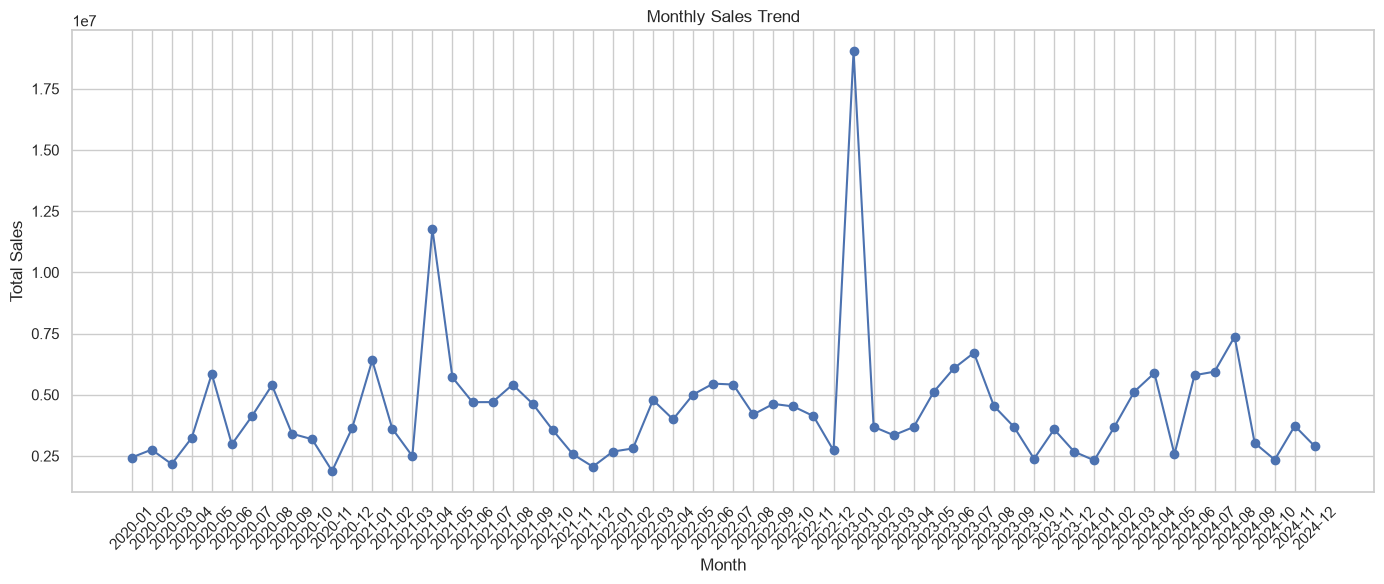

In [34]:
# Plot monthly sales trend

plt.figure(figsize=(14, 6))

plt.plot(
    monthly_sales.index.astype(str),
    monthly_sales.values,
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Observation

The monthly sales trend shows considerable variation throughout the five-year period. Most months record moderate sales, while a few months show unusually high sales spikes.

A major sales peak is observed around December 2022, with another notable spike around March 2021. These unusual peaks may be associated with high-value transactions, seasonal demand, promotions, or other business factors and can be investigated further.

### 3.2 Quarterly Sales Trend

Quarterly sales analysis provides a broader view of sales performance by grouping transactions into three-month periods. It helps identify seasonal patterns and compare sales performance across quarters.

In [35]:
# Calculate total sales for each quarter

quarterly_sales = df.groupby(
    df["order_date"].dt.to_period("Q")
)["sales_amount"].sum()

quarterly_sales.head()

order_date
2020Q1     7359879.99
2020Q2    12065576.13
2020Q3    12919000.43
2020Q4     8710815.69
2021Q1    12516345.20
Freq: Q-DEC, Name: sales_amount, dtype: float64

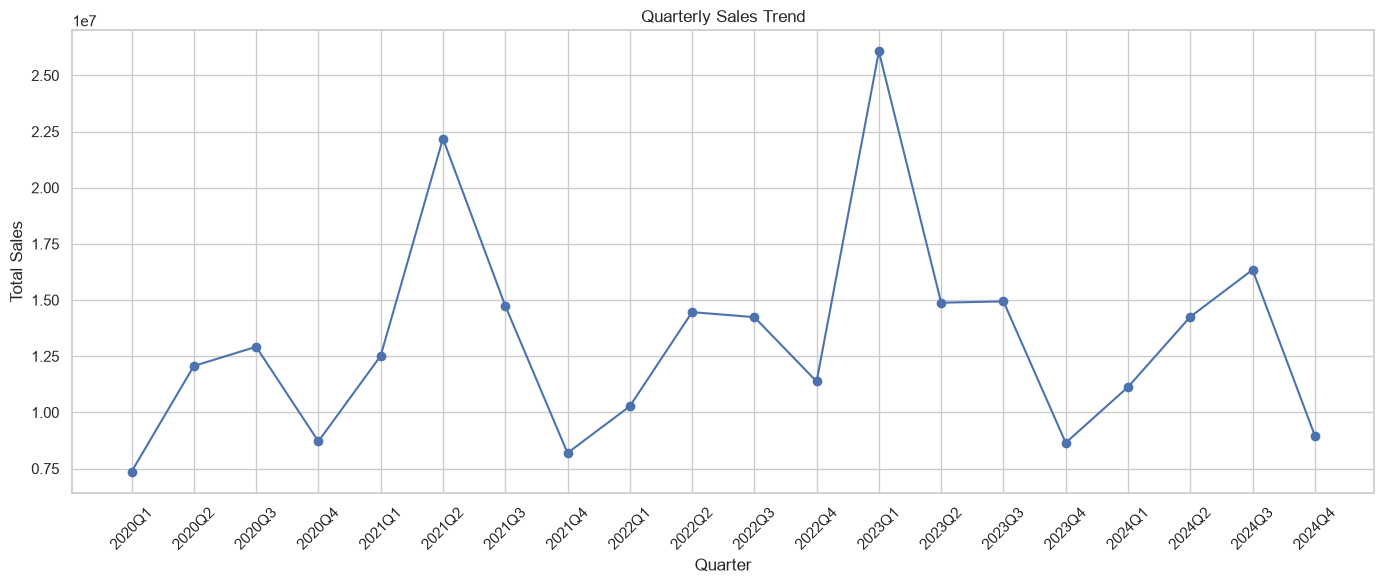

In [36]:
# Plot quarterly sales trend

plt.figure(figsize=(14, 6))

plt.plot(
    quarterly_sales.index.astype(str),
    quarterly_sales.values,
    marker="o"
)

plt.title("Quarterly Sales Trend")
plt.xlabel("Quarter")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Observation

The quarterly sales trend shows significant variation across the five-year period. Sales increased during several quarters, with notable peaks in 2021 Q2 and 2023 Q1. The highest quarterly sales were observed in 2023 Q1 at approximately 26 million.

Sales also experienced noticeable declines in some quarters, particularly after major peaks. Overall, the quarterly pattern indicates fluctuating sales performance rather than a consistent upward or downward trend.

### 4.1 Age Group Distribution

Age-group analysis helps identify the major customer segments based on age. Customers are grouped into meaningful age ranges to make the distribution easier to interpret.

In [37]:
# Create age groups

bins = [17, 25, 35, 45, 55, 65, 72]
labels = ["18-25", "26-35", "36-45", "46-55", "56-65", "66-72"]

df["age_group"] = pd.cut(
    df["age"],
    bins=bins,
    labels=labels
)

df["age_group"].value_counts().sort_index()

age_group
18-25     614
26-35    1753
36-45    1100
46-55     579
56-65     138
66-72      16
Name: count, dtype: int64

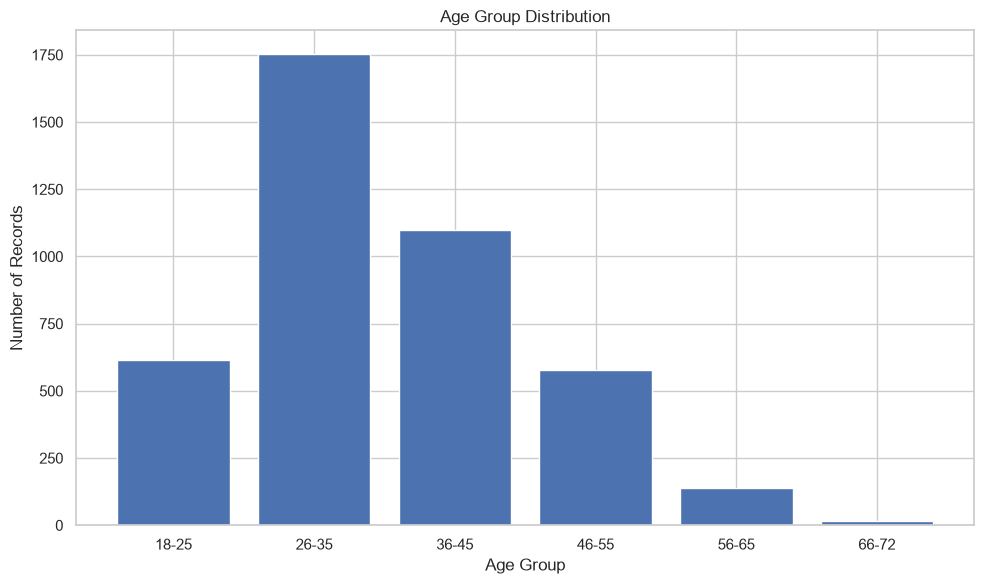

In [38]:
# Count customers/orders in each age group

age_group_counts = df["age_group"].value_counts().sort_index()

plt.figure(figsize=(10, 6))

plt.bar(
    age_group_counts.index,
    age_group_counts.values
)

plt.title("Age Group Distribution")
plt.xlabel("Age Group")
plt.ylabel("Number of Records")

plt.tight_layout()
plt.show()

### Observation

The age group distribution shows that customers aged 26–35 form the largest segment with 1,753 records, followed by the 36–45 age group with 1,100 records. Customers aged 56 and above are comparatively less represented, especially the 66–72 group.

This indicates that the retail business has a stronger representation of customers in the 26–45 age range, which can help in planning targeted marketing campaigns and product offerings.

### 4.2 Gender Distribution

Gender analysis helps understand the distribution of customers across different gender categories and provides insights into the customer base.

In [39]:
# Count records by gender

gender_counts = df["gender"].value_counts()

gender_counts

gender
Other     1419
Male      1178
Female    1172
male        67
MALE        61
f           55
F           53
m           53
M           49
FEMALE      48
female      45
Name: count, dtype: int64

In [40]:
# Standardize gender values

df["gender_clean"] = df["gender"].astype(str).str.strip().str.lower()

df["gender_clean"] = df["gender_clean"].replace({
    "m": "Male",
    "male": "Male",
    "f": "Female",
    "female": "Female",
    "other": "Other"
})

gender_counts = df["gender_clean"].value_counts()

gender_counts

gender_clean
Other     1419
Male      1408
Female    1373
Name: count, dtype: int64

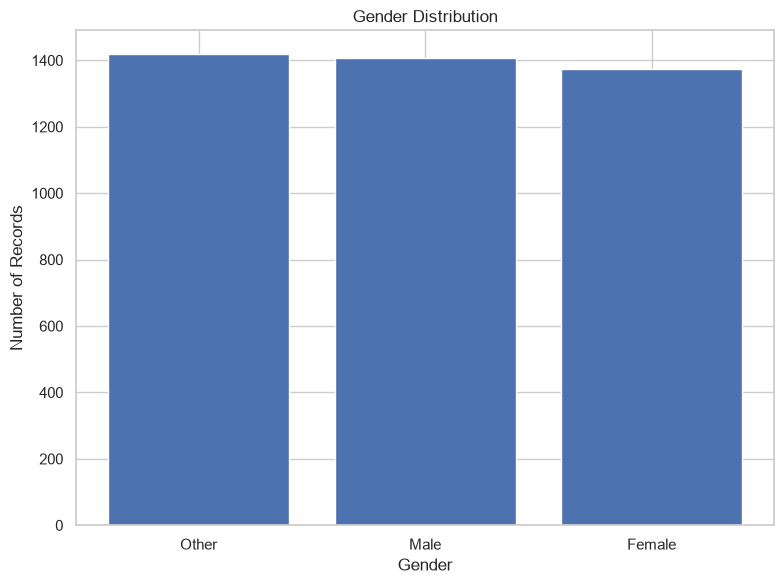

In [41]:
# Plot gender distribution

plt.figure(figsize=(8, 6))

plt.bar(
    gender_counts.index,
    gender_counts.values
)

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Records")

plt.tight_layout()
plt.show()

### Observation

The gender distribution is relatively balanced across the three categories. The "Other" category has the highest representation with 1,419 records, followed by Male with 1,408 records and Female with 1,373 records.

The relatively even distribution suggests that the dataset represents customers across different gender categories without a strong dominance of any single category.

### 5.1 Top 10 Best-Selling Products

Product-level analysis helps identify which products have the highest sales volume. The top-selling products are determined by the total quantity sold across all transactions.

In [42]:
# Calculate total quantity sold for each product

product_sales = (
    df.groupby("product_name")["quantity"]
    .sum()
    .sort_values(ascending=False)
)

product_sales.head(10)

product_name
Desk          664.0
Laptop        661.0
Textbook      652.0
Face Cream    630.0
Headphones    622.0
Kurta         619.0
Sunscreen     611.0
Dal (1kg)     610.0
Shampoo       609.0
Smartwatch    601.0
Name: quantity, dtype: float64

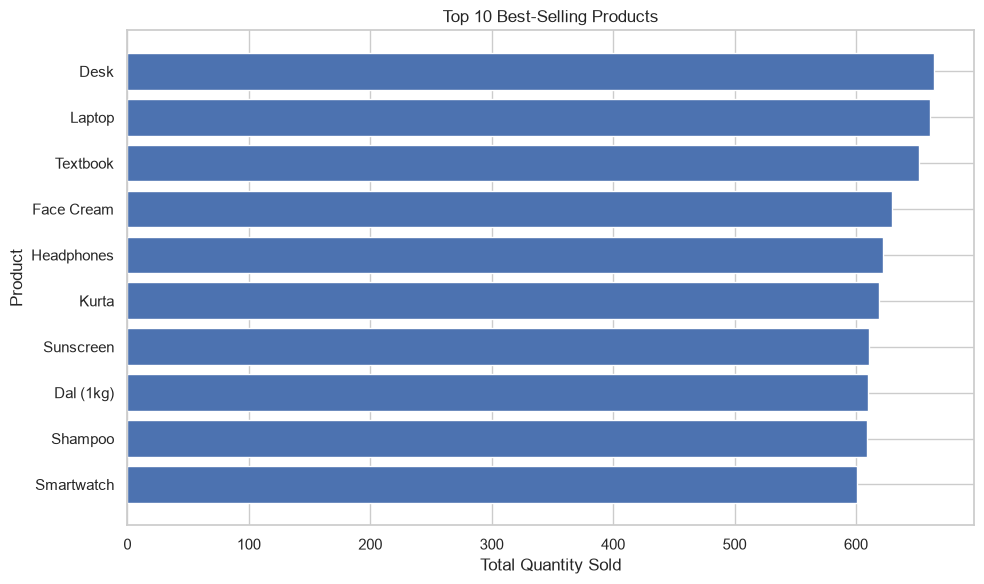

In [43]:
# Select top 10 best-selling products

top_10_products = product_sales.head(10).sort_values()

plt.figure(figsize=(10, 6))

plt.barh(
    top_10_products.index,
    top_10_products.values
)

plt.title("Top 10 Best-Selling Products")
plt.xlabel("Total Quantity Sold")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

### Observation

The top 10 best-selling products show relatively similar sales volumes, ranging from 601 to 664 units. Desk has the highest quantity sold with 664 units, followed by Laptop with 661 units and Textbook with 652 units.

The small difference between these products indicates that sales volume is distributed across multiple products rather than being dominated by a single product.

### 5.2 Revenue by Product Category

Revenue analysis helps identify which product categories contribute the most to overall sales. Total revenue is calculated by summing the sales amount for each product category.

In [44]:
# Calculate total revenue by product category

category_revenue = (
    df.groupby("product_category")["sales_amount"]
    .sum()
    .sort_values(ascending=False)
)

category_revenue

product_category
Electronics    1.556426e+08
Furniture      5.670920e+07
Sports         3.168667e+07
Clothing       1.156374e+07
Beauty         3.881089e+06
Books          3.777514e+06
Groceries      1.009020e+06
Name: sales_amount, dtype: float64

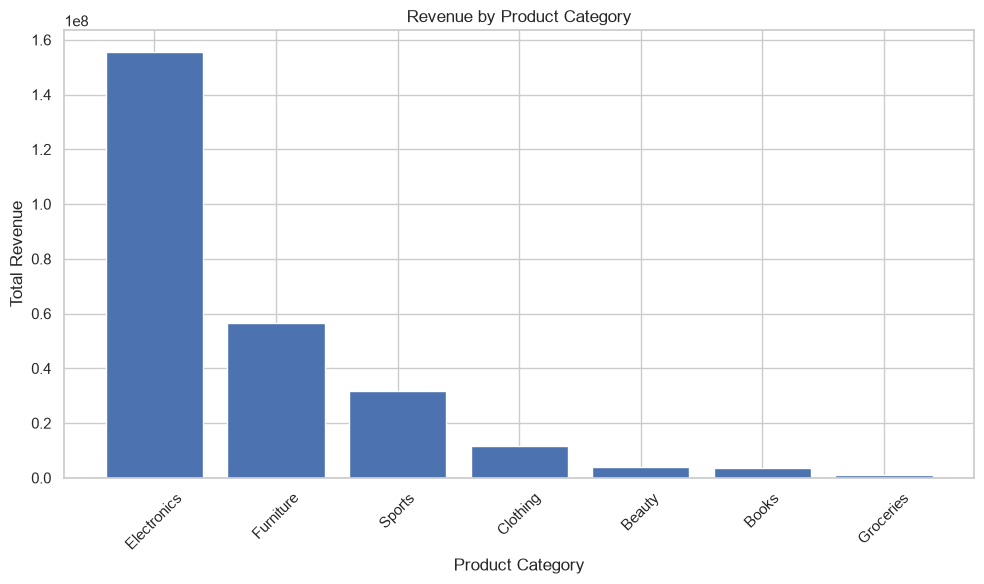

In [45]:
# Plot revenue by product category

plt.figure(figsize=(10, 6))

plt.bar(
    category_revenue.index,
    category_revenue.values
)

plt.title("Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Revenue")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Observation

Electronics is the highest revenue-generating product category, contributing approximately 155.64 million in total sales. Furniture is the second-highest contributor, followed by Sports and Clothing.

The high revenue contribution from Electronics indicates strong demand for this category. The business can focus on maintaining adequate inventory and expanding successful electronics products to support revenue growth.

## 6. Correlation Matrix Heatmap

Correlation analysis is used to understand the relationships between numerical variables in the retail sales dataset. A correlation matrix heatmap provides a visual representation of these relationships and helps identify variables that have strong positive or negative correlations.

In [7]:
# Calculate correlation between numerical variables

correlation_matrix = df[numerical_columns].corr()

correlation_matrix

,age,quantity,unit_price,discount_pct,sales_amount,profit,shipping_cost,customer_satisfaction,days_to_ship
age,1.000000,0.145792,-0.013138,-0.025448,0.347677,0.295303,0.003787,0.012175,-0.006769
quantity,0.145792,1.000000,-0.013292,-0.024438,0.539590,0.661070,0.015221,-0.006295,-0.017048
unit_price,-0.013138,-0.013292,1.000000,-0.022573,0.295509,0.233631,0.014112,-0.012088,0.010746
discount_pct,-0.025448,-0.024438,-0.022573,1.000000,-0.047342,-0.046895,-0.006710,-0.007345,0.011488
sales_amount,0.347677,0.539590,0.295509,-0.047342,1.000000,0.948788,0.026577,-0.025612,-0.005117
profit,0.295303,0.661070,0.233631,-0.046895,0.948788,1.000000,0.026567,-0.024395,-0.008014
shipping_cost,0.003787,0.015221,0.014112,-0.006710,0.026577,0.026567,1.000000,0.016349,0.009083
customer_satisfaction,0.012175,-0.006295,-0.012088,-0.007345,-0.025612,-0.024395,0.016349,1.000000,-0.010519
days_to_ship,-0.006769,-0.017048,0.010746,0.011488,-0.005117,-0.008014,0.009083,-0.010519,1.000000


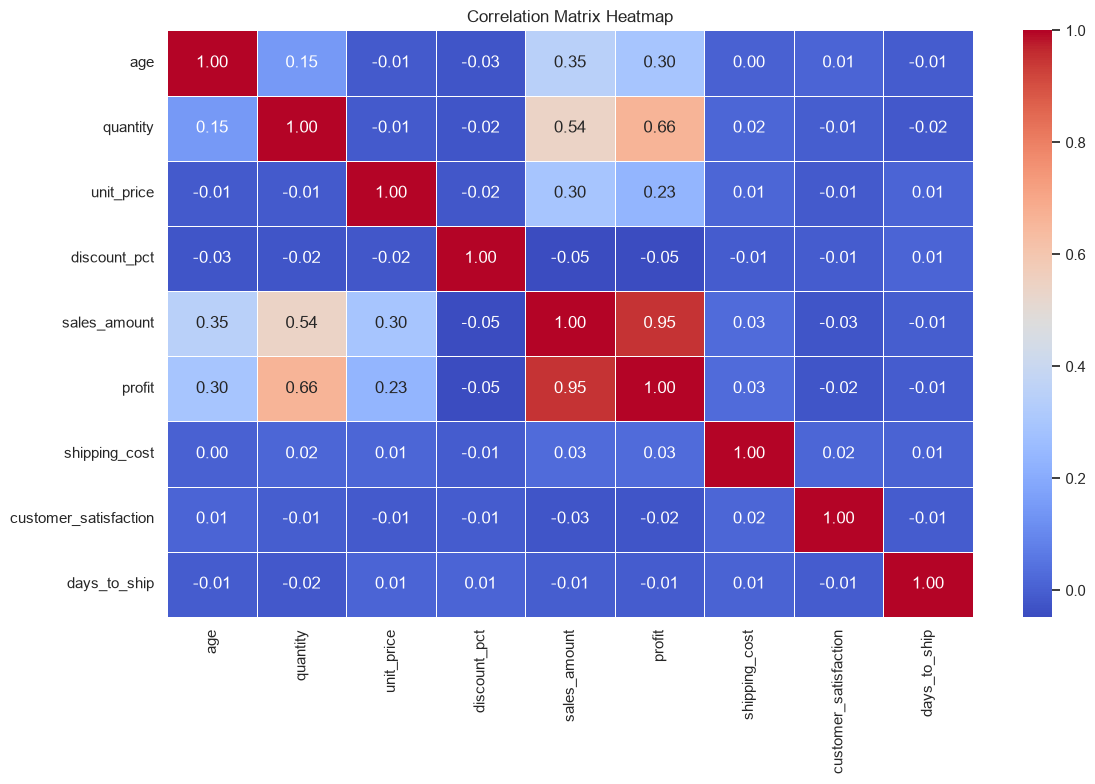

In [8]:
# Plot correlation matrix as a heatmap

plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Matrix Heatmap")
plt.tight_layout()
plt.show()

### Observation

The heatmap shows a very strong positive correlation between sales amount and profit (0.95), indicating that higher sales are generally associated with higher profit. Quantity also has a positive correlation with profit (0.66) and sales amount (0.54).

Most other variables show weak or near-zero correlations, suggesting limited linear relationships. Discount percentage has a very weak negative correlation with sales amount (-0.05), while customer satisfaction and days to ship have almost no correlation with sales amount.

## 7. Additional Visualization

To identify an additional business insight, we will analyze total profit by product category. This helps compare profitability across categories and understand which categories contribute most to the overall profit.

In [9]:
# Calculate total profit by product category

category_profit = (
    df.groupby("product_category")["profit"]
    .sum()
    .sort_values(ascending=False)
)

category_profit

product_category
Electronics    19295549.67
Furniture      16134849.68
Sports          7079357.54
Clothing        4212780.97
Beauty          1792922.71
Books           1424006.08
Groceries         81428.58
Name: profit, dtype: float64

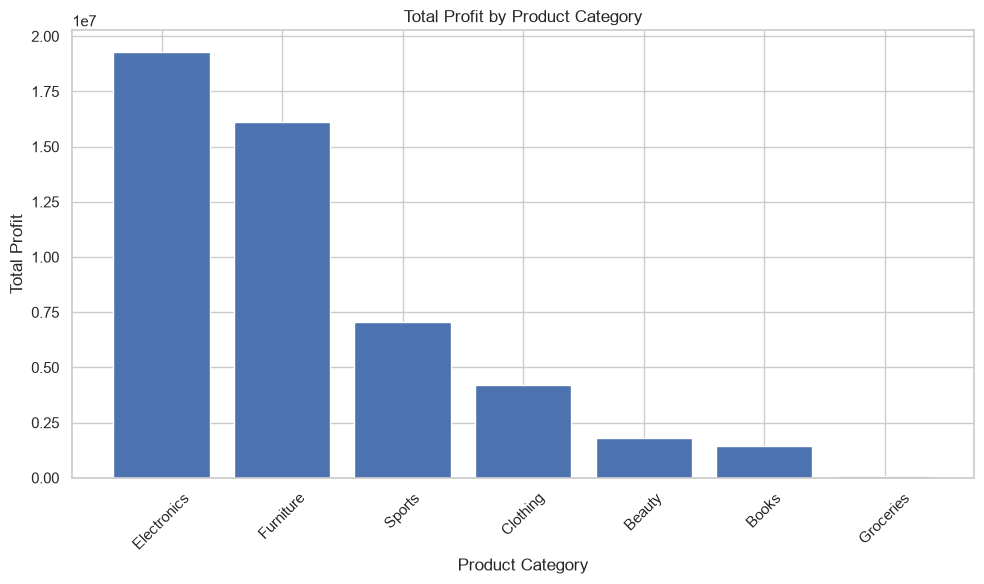

In [10]:
# Plot total profit by product category

plt.figure(figsize=(10, 6))

plt.bar(
    category_profit.index,
    category_profit.values
)

plt.title("Total Profit by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Profit")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Observation

The profit distribution shows that Electronics generates the highest total profit at approximately 19.30 million, followed by Furniture at approximately 16.13 million. Sports and Clothing contribute moderate levels of profit, while Groceries generate the lowest profit.

This indicates that Electronics and Furniture are the most profitable categories and should receive greater attention in terms of inventory planning, product availability, and business strategy.

## 8. Conclusion

The Exploratory Data Analysis provided useful insights into sales performance, customer demographics, product demand, and profitability. The analysis showed that customers aged 26–35 form the largest age group, Electronics generates the highest revenue and profit, and sales and profit have a very strong positive correlation.

The analysis also identified fluctuations in monthly and quarterly sales, with several noticeable sales peaks. These insights can help the business improve inventory planning, marketing strategies, and overall sales performance.

### Actionable Business Recommendations

1. **Focus on Electronics and Furniture:**  
   Since these categories generate the highest revenue and profit, the business should maintain sufficient inventory and promote high-performing products in these categories.

2. **Target the 26–45 Age Group:**  
   This is the largest customer segment in the dataset. Marketing campaigns and product offers can be designed specifically for this age group.

3. **Improve Sales Planning Around Peak Periods:**  
   Sales show significant fluctuations and several high-sales periods. The business should prepare inventory and promotional campaigns before expected peak periods.

4. **Increase Focus on High-Selling Products:**  
   Products such as Desk, Laptop, and Textbook have high sales quantities. Maintaining their availability can help prevent missed sales opportunities.

5. **Monitor Low-Profit Categories:**  
   Categories such as Groceries, Books, and Beauty generate comparatively lower total profit. Their pricing, costs, and product demand should be reviewed to identify opportunities for improvement.